# Visualización y análisis de resultados.

**Descripción**.

En esta notebook se recupera la información de la simulación de flujo de agua subterránea y transporte conservativo de la componente $U = c_1 - c_2$, donde $c_1= SO_4^{2-}$ y  $c_2 =  Ca^{2+}$.  Una vez recuperada la información, se visualiza usando las funciones implementadas en el archivo [`vis.py`](vis.py).

<a href="https://github.com/luiggix/RTWMA">RTWMA</a> © 2024-2026 by <a href="https://www.geofisica.unam.mx">IGF-UNAM</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc/4.0/">CC BY-NC 4.0</a><img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/by.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/nc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;">

# Recuperación de la información.

Usamos la función `data_recovery()` del módulo `vis.py` para recuperar la información de los cálculos. Esta función requiere de los objetos de los modelos de flujo y transporte, los cuales se pueden crear a partir de los archivos de resultados como sigue.

In [3]:
import vis
import flopy

In [4]:
# Cargamos el modelo de flujo
o_sim_f = flopy.mf6.MFSimulation.load(
    sim_ws="output_gwf_U/",
    verbosity_level=0,
)

# Cargamos el modelo de transporte
o_sim_t = flopy.mf6.MFSimulation.load(
    sim_ws="output_gwt_U/",
    verbosity_level=0,
)

# Obtenemos los objetos de cada modelo
o_gwf = o_sim_f.get_model("flow")
o_gwt = o_sim_t.get_model("transport")

Ahora recuperamos la información a partir de los objetos `o_gwf` y `o_gwt`:

In [5]:
x, head, qx, qy, o_conc, times_c = vis.data_recovery(o_gwf, o_gwt)


Carga hidráulica
――――――――――――――――
 xcoord = ―― data array ――
        = [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]
times_h = ―― data array ――
        = [40.]
   head = ―― data array ――
        = [6.8 6.6 6.4 6.2 6.  5.8 5.6 5.4 5.2 5.  4.8 4.6 4.4 4.2 4.  3.8 3.6 3.4
 3.2 3.  2.8 2.6 2.4 2.2 2.  1.8 1.6 1.4 1.2 1. ]
     qx = ―― data array ――
        = [[0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
  0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]]
――――――――――――――――

Concentración
―――――――――――――
xcoord = ―― data array ――
       = [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]
 times = ―― data array ――
       = [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 

Realizamos la graficación con la función `vis.plot()`:

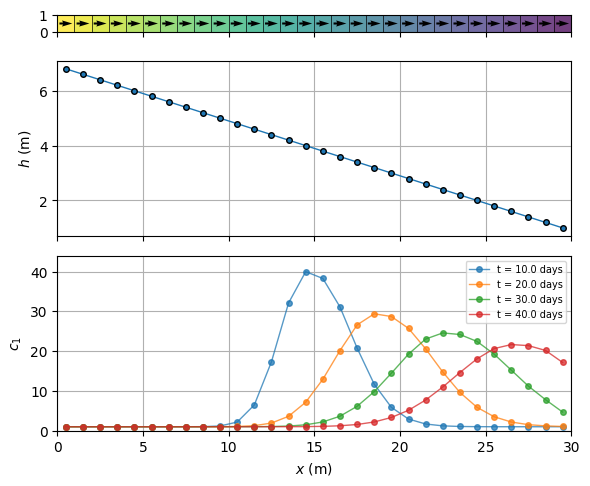

In [6]:
vis.plot(o_gwf, x, head, qx, qy, o_conc, times_c)

Graficamos como función del tiempo en las celdas de observación (5, 11, 12, 30) usando la función `vis.plot_obs()`:

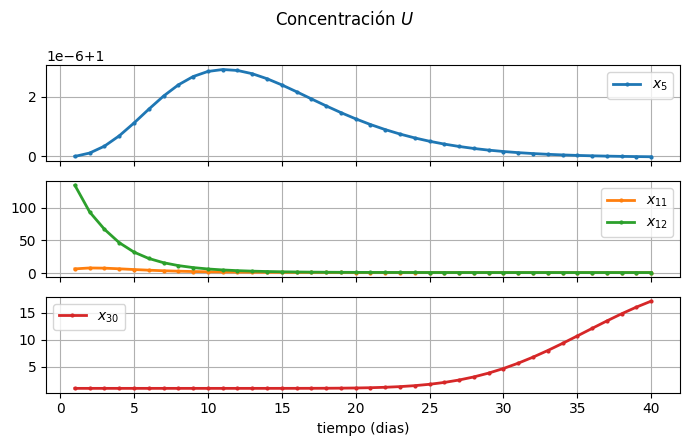

In [7]:
vis.plot_obs(o_conc, times_c)